In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import butter, filtfilt, iirnotch
import pywt

In [2]:
# ── Reload Record 100, same as Month 1 ──────────────────────────────────
record = wfdb.rdrecord('100', sampfrom=0, sampto=3600, pn_dir='mitdb')
ecg_signal = record.p_signal[:, 0]
fs = record.fs
t = np.arange(len(ecg_signal)) / fs

# ── Rebuild filter functions from Month 1 ───────────────────────────────
def highpass_filter(signal, cutoff, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff/nyq, btype='high')
    return filtfilt(b, a, signal)

def notch_filter(signal, notch_freq, fs, quality_factor=30):
    b, a = iirnotch(notch_freq, quality_factor, fs)
    return filtfilt(b, a, signal)

def lowpass_filter(signal, cutoff, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff/nyq, btype='low')
    return filtfilt(b, a, signal)

def compute_snr(original, noise):
    signal_power = np.mean(original**2)
    noise_power = np.mean(noise**2)
    return 10*np.log10(signal_power/noise_power)

def compute_nrmse(reference, estimated):
    rmse = np.sqrt(np.mean((reference-estimated)**2))
    return rmse/(reference.max()-reference.min())

# ── Derive clean reference (same method as Month 1) ─────────────────────
sig_hp = highpass_filter(ecg_signal, cutoff=0.5, fs=fs)
sig_notch = notch_filter(sig_hp, notch_freq=50, fs=fs)
ecg_clean = lowpass_filter(sig_notch, cutoff=40, fs=fs)

# ── Add same synthetic noise as Month 1 ──────────────────────────────────
np.random.seed(42)
noise = (0.1 * np.sin(2*np.pi*0.3*t) +      # baseline wander
         0.05 * np.sin(2*np.pi*50*t) +       # powerline
         0.1 * np.random.randn(len(ecg_clean)))  # muscle artifact
ecg_noisy = ecg_clean + noise

print(f"Loaded: fs={fs} Hz, signal length={len(ecg_signal)} samples ({len(ecg_signal)/fs:.1f}s)")
print(f"ecg_clean, ecg_noisy ready — same as Month 1 baseline")

Loaded: fs=360 Hz, signal length=3600 samples (10.0s)
ecg_clean, ecg_noisy ready — same as Month 1 baseline


In [3]:
# Load your existing clean/noisy signals from Month 1 (reuse ecg_clean, fs, t)
# ── CWT parameters ──────────────────────────────────────────────────────
# Morlet wavelet: shape resembles QRS complex, standard choice in ECG literature
wavelet = 'morl'

# Scale range: chosen to map to 0.5-40 Hz (same diagnostic range as Month 1)
# Higher scales = lower frequencies, lower scales = higher frequencies
scales = np.arange(1, 128)

# Compute CWT
coefficients, frequencies = pywt.cwt(ecg_clean, scales, wavelet, sampling_period=1/fs)

print(f"Coefficient matrix shape: {coefficients.shape}")
print(f"Frequency range covered: {frequencies.min():.2f} Hz to {frequencies.max():.2f} Hz")

Coefficient matrix shape: (127, 3600)
Frequency range covered: 2.30 Hz to 292.50 Hz


In [4]:
# ── Find exact scales for our target frequency range (0.5-40 Hz) ────────
# pywt.scale2frequency converts scale -> frequency for a given wavelet
# We work backwards: frequency -> scale

target_freqs = np.array([0.5, 40])  # our diagnostic range boundaries
# scale = center_frequency / (target_freq * sampling_period)
central_freq = pywt.central_frequency(wavelet)
scales_needed = central_freq / (target_freqs * (1/fs))

print(f"Morlet central frequency: {central_freq:.4f}")
print(f"Scale needed for 0.5 Hz: {scales_needed[0]:.1f}")
print(f"Scale needed for 40 Hz: {scales_needed[1]:.1f}")

Morlet central frequency: 0.8125
Scale needed for 0.5 Hz: 585.0
Scale needed for 40 Hz: 7.3


In [5]:
# ── Corrected scale range: log-spaced from 7 to 585 ──────────────────────
# Log spacing gives better resolution at low frequencies (large scales)
# where small scale changes cause large frequency changes
scales = np.logspace(np.log10(7), np.log10(585), num=150)

coefficients, frequencies = pywt.cwt(ecg_clean, scales, wavelet, sampling_period=1/fs)

print(f"Coefficient matrix shape: {coefficients.shape}")
print(f"Frequency range covered: {frequencies.min():.2f} Hz to {frequencies.max():.2f} Hz")

Coefficient matrix shape: (150, 3600)
Frequency range covered: 0.50 Hz to 41.79 Hz


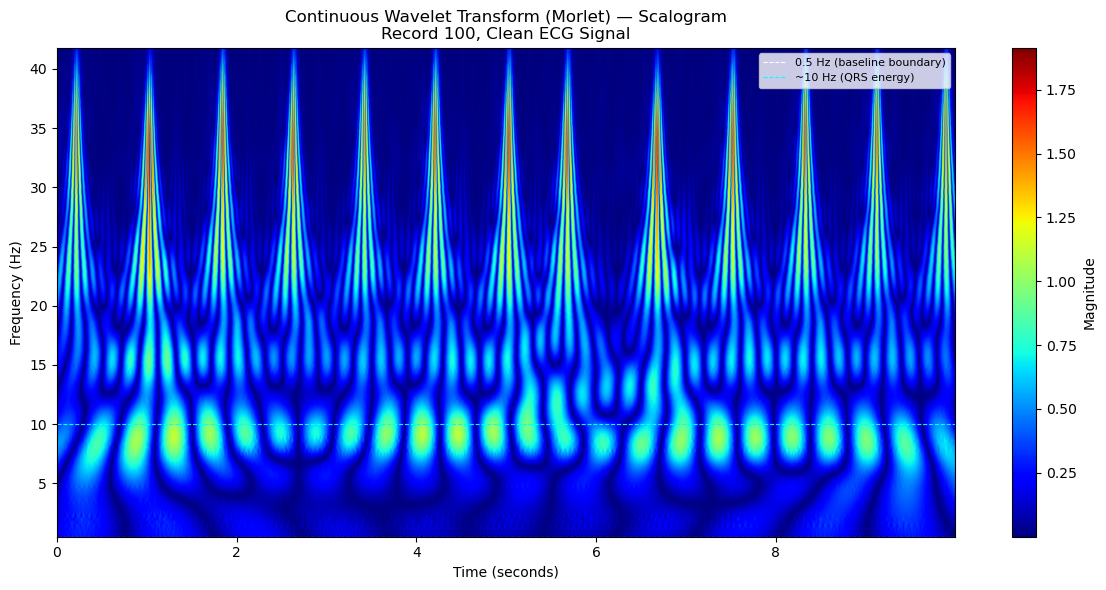

In [6]:
plt.figure(figsize=(12, 6))

# Scalogram: magnitude of CWT coefficients
plt.imshow(np.abs(coefficients), extent=[t[0], t[-1], frequencies[-1], frequencies[0]],
           cmap='jet', aspect='auto', interpolation='bilinear')

plt.colorbar(label='Magnitude')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (seconds)')
plt.title('Continuous Wavelet Transform (Morlet) — Scalogram\nRecord 100, Clean ECG Signal')

# Mark key frequency bands, same reference lines as your Week 3 spectrogram
plt.axhline(y=0.5, color='white', linewidth=0.8, linestyle='--', label='0.5 Hz (baseline boundary)')
plt.axhline(y=10, color='cyan', linewidth=0.8, linestyle='--', label='~10 Hz (QRS energy)')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('output images/scalogram_clean.png', dpi=150)
plt.show()

In [7]:
wavelet_dwt = 'db6'
level = 5  # decomposition depth - covers our 0.5-40Hz range at fs=360Hz

coeffs = pywt.wavedec(ecg_noisy, wavelet_dwt, level=level)

print(f"Number of coefficient arrays: {len(coeffs)}")
for i, c in enumerate(coeffs):
    label = "Approximation" if i == 0 else f"Detail level {level - i + 1}"
    print(f"{label}: {len(c)} coefficients")

Number of coefficient arrays: 6
Approximation: 123 coefficients
Detail level 5: 123 coefficients
Detail level 4: 235 coefficients
Detail level 3: 459 coefficients
Detail level 2: 908 coefficients
Detail level 1: 1805 coefficients


In [8]:
# Estimate noise sigma from finest detail coefficients (level 1)
detail_coeffs_L1 = coeffs[-1]
sigma = np.median(np.abs(detail_coeffs_L1)) / 0.6745  # robust estimator

N = len(ecg_noisy)
universal_threshold = sigma * np.sqrt(2 * np.log(N))

print(f"Estimated sigma: {sigma:.4f}")
print(f"Universal threshold: {universal_threshold:.4f}")

# Apply soft thresholding to detail coefficients only (keep approximation untouched)
coeffs_thresholded = [coeffs[0]] + [
    pywt.threshold(c, universal_threshold, mode='soft') for c in coeffs[1:]
]

# Reconstruct denoised signal
ecg_wavelet_denoised = pywt.waverec(coeffs_thresholded, wavelet_dwt)

# Trim to original length (waverec can add 1 extra sample)
ecg_wavelet_denoised = ecg_wavelet_denoised[:len(ecg_noisy)]

snr_wavelet = compute_snr(ecg_clean, ecg_wavelet_denoised - ecg_clean)
nrmse_wavelet = compute_nrmse(ecg_clean, ecg_wavelet_denoised)

print(f"Wavelet denoised SNR: {snr_wavelet:.2f} dB")
print(f"Wavelet denoised NRMSE: {nrmse_wavelet:.4f}")
print(f"\nCompare to Month 1:")
print(f"Butterworth: 20.11 dB")
print(f"FIR Kaiser : 19.35 dB")

Estimated sigma: 0.1021
Universal threshold: 0.4132
Wavelet denoised SNR: 3.92 dB
Wavelet denoised NRMSE: 0.0694

Compare to Month 1:
Butterworth: 20.11 dB
FIR Kaiser : 19.35 dB


In [9]:
# Estimate sigma per level (not just from level 1) for level-specific thresholds
def level_dependent_threshold(coeffs, N):
    thresholded = [coeffs[0]]  # keep approximation untouched
    for c in coeffs[1:]:
        sigma_level = np.median(np.abs(c)) / 0.6745
        thresh = sigma_level * np.sqrt(2 * np.log(N))
        thresholded.append(pywt.threshold(c, thresh, mode='soft'))
    return thresholded

N = len(ecg_noisy)
coeffs_level_thresh = level_dependent_threshold(coeffs, N)

ecg_wavelet_denoised_v2 = pywt.waverec(coeffs_level_thresh, wavelet_dwt)
ecg_wavelet_denoised_v2 = ecg_wavelet_denoised_v2[:len(ecg_noisy)]

snr_wavelet_v2 = compute_snr(ecg_clean, ecg_wavelet_denoised_v2 - ecg_clean)
nrmse_wavelet_v2 = compute_nrmse(ecg_clean, ecg_wavelet_denoised_v2)

print(f"Level-dependent wavelet SNR: {snr_wavelet_v2:.2f} dB")
print(f"Level-dependent wavelet NRMSE: {nrmse_wavelet_v2:.4f}")
print(f"\nCompare:")
print(f"Uniform threshold : {snr_wavelet:.2f} dB")
print(f"Butterworth        : 20.11 dB")
print(f"FIR Kaiser          : 19.35 dB")

Level-dependent wavelet SNR: 2.09 dB
Level-dependent wavelet NRMSE: 0.0858

Compare:
Uniform threshold : 3.92 dB
Butterworth        : 20.11 dB
FIR Kaiser          : 19.35 dB


In [10]:
# Recompute DWT fresh every time - avoid stale/mutated state
coeffs_fresh = pywt.wavedec(ecg_noisy, wavelet_dwt, level=level)

# ── Uniform threshold ──
detail_L1 = coeffs_fresh[-1]
sigma_uniform = np.median(np.abs(detail_L1)) / 0.6745
N = len(ecg_noisy)
uniform_thresh = sigma_uniform * np.sqrt(2 * np.log(N))

coeffs_uniform = [coeffs_fresh[0]] + [
    pywt.threshold(c, uniform_thresh, mode='soft') for c in coeffs_fresh[1:]
]
ecg_uniform = pywt.waverec(coeffs_uniform, wavelet_dwt)[:len(ecg_noisy)]

snr_uniform = compute_snr(ecg_clean, ecg_uniform - ecg_clean)
nrmse_uniform = compute_nrmse(ecg_clean, ecg_uniform)

# ── Level-dependent threshold (fresh coeffs again) ──
coeffs_fresh2 = pywt.wavedec(ecg_noisy, wavelet_dwt, level=level)
coeffs_leveldep = [coeffs_fresh2[0]]
for c in coeffs_fresh2[1:]:
    sigma_level = np.median(np.abs(c)) / 0.6745
    thresh = sigma_level * np.sqrt(2 * np.log(N))
    coeffs_leveldep.append(pywt.threshold(c, thresh, mode='soft'))

ecg_leveldep = pywt.waverec(coeffs_leveldep, wavelet_dwt)[:len(ecg_noisy)]

snr_leveldep = compute_snr(ecg_clean, ecg_leveldep - ecg_clean)
nrmse_leveldep = compute_nrmse(ecg_clean, ecg_leveldep)

print(f"Uniform threshold    : SNR={snr_uniform:.2f} dB, NRMSE={nrmse_uniform:.4f}")
print(f"Level-dependent      : SNR={snr_leveldep:.2f} dB, NRMSE={nrmse_leveldep:.4f}")
print(f"Butterworth (Month1) : SNR=20.11 dB")
print(f"FIR Kaiser (Month1)  : SNR=19.35 dB")

Uniform threshold    : SNR=3.92 dB, NRMSE=0.0694
Level-dependent      : SNR=2.09 dB, NRMSE=0.0858
Butterworth (Month1) : SNR=20.11 dB
FIR Kaiser (Month1)  : SNR=19.35 dB


In [11]:
np.random.seed(42)

# Three isolated noise signals
noise_gaussian_only = 0.1 * np.random.randn(len(ecg_clean))
noise_baseline_only = 0.1 * np.sin(2*np.pi*0.3*t)
noise_powerline_only = 0.05 * np.sin(2*np.pi*50*t)

ecg_gaussian_noisy = ecg_clean + noise_gaussian_only
ecg_baseline_noisy = ecg_clean + noise_baseline_only
ecg_powerline_noisy = ecg_clean + noise_powerline_only

def wavelet_denoise(signal, wavelet_name='db6', level=5):
    coeffs = pywt.wavedec(signal, wavelet_name, level=level)
    detail_L1 = coeffs[-1]
    sigma = np.median(np.abs(detail_L1)) / 0.6745
    N = len(signal)
    thresh = sigma * np.sqrt(2 * np.log(N))
    coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, thresh, mode='soft') for c in coeffs[1:]]
    denoised = pywt.waverec(coeffs_thresh, wavelet_name)
    return denoised[:len(signal)]

# Denoise each isolated case
den_gaussian = wavelet_denoise(ecg_gaussian_noisy)
den_baseline = wavelet_denoise(ecg_baseline_noisy)
den_powerline = wavelet_denoise(ecg_powerline_noisy)

# Metrics
for name, noisy, denoised in [
    ("Gaussian only", ecg_gaussian_noisy, den_gaussian),
    ("Baseline only", ecg_baseline_noisy, den_baseline),
    ("Powerline only", ecg_powerline_noisy, den_powerline),
]:
    snr_before = compute_snr(ecg_clean, noisy - ecg_clean)
    snr_after = compute_snr(ecg_clean, denoised - ecg_clean)
    print(f"{name:15s}: SNR before={snr_before:.2f} dB -> after={snr_after:.2f} dB (Δ={snr_after-snr_before:+.2f})")

Gaussian only  : SNR before=4.38 dB -> after=6.54 dB (Δ=+2.16)
Baseline only  : SNR before=7.38 dB -> after=7.38 dB (Δ=-0.00)
Powerline only : SNR before=13.40 dB -> after=16.31 dB (Δ=+2.91)
